## binagem de 60 segundos

#### Banda 3-10keV (correção de fundo no final do notebook)

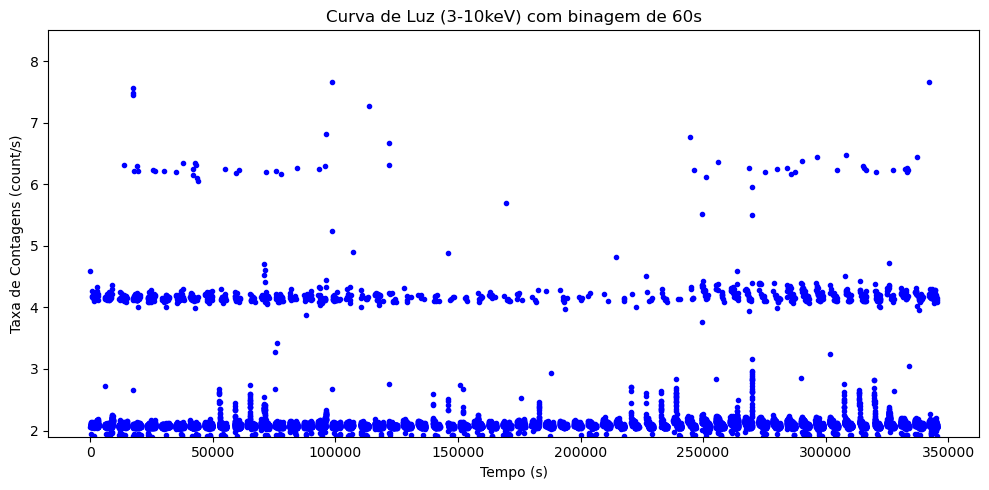

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

caminho = 'data/ bins 60s/3-10kev/lc_fonte_sub_3-10kev.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10keV) com binagem de 60s')
plt.ylim(1.9,8.5)


plt.tight_layout()
plt.show()

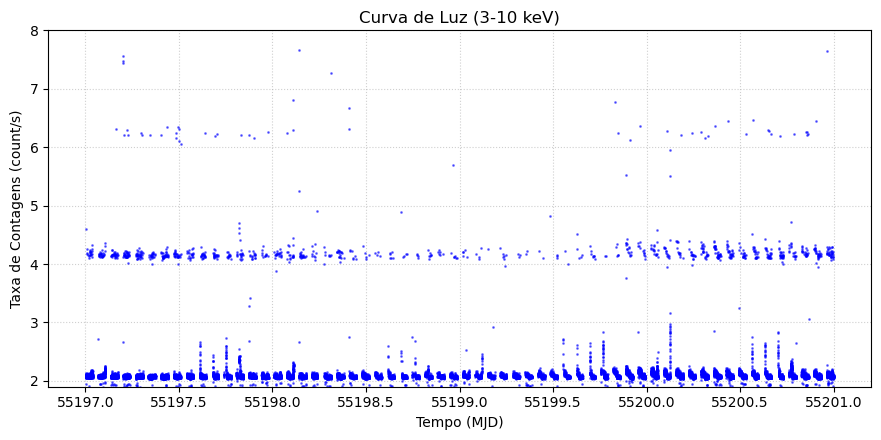

In [39]:
import matplotlib.pyplot as plt
from astropy.table import Table

caminho = 'data/ bins 60s/3-10kev/lc_fonte_sub_3-10kev.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.plot(df['MJD'], df['RATE'], 'b.', alpha=0.5, markersize=2)
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10 keV)')
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.ylim(1.9,8)
plt.show()

Melhor frequência: 14.8047 dias⁻¹ (P = 0.07 dias)
Frequência esperada: 0.2560 dias⁻¹ (P = 3.90603 dias)


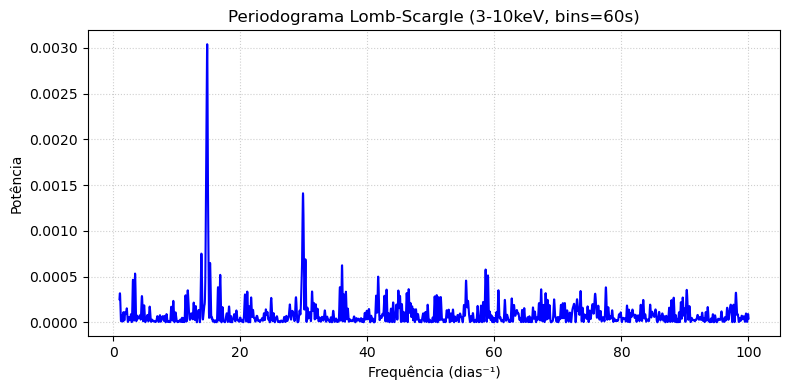

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/ bins 60s/3-10kev/lc_fonte_sub_3-10kev.lc'
tabela = Table.read(caminho, hdu=1)

time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)

t_dias = time[mask] / 86400.0
rate_clean = rate[mask] - np.mean(rate[mask]) 

min_p, max_p = 0.01, 1.0
freq_min, freq_max = 1 / max_p, 1 / min_p

ls = LombScargle(t_dias, rate_clean, err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max, samples_per_peak=10
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

p_esperado = 3.90603  
f_esperado = 1 / p_esperado

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹ (P = {best_p:.2f} dias)')
print(f'Frequência esperada: {f_esperado:.4f} dias⁻¹ (P = {p_esperado} dias)')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'b-', lw=1.5)
#plt.axvline(
 #   f_esperado,
  #  color='r',
   # ls='--',
   # label=f'Esperado (P = {p_esperado} d)',
#)
#plt.axvline(
 #   best_freq, color='k', ls=':', label=f'Pico (P = {best_p:.2f} d)'
#)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle (3-10keV, bins=60s)')
#plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### banda 10-30keV

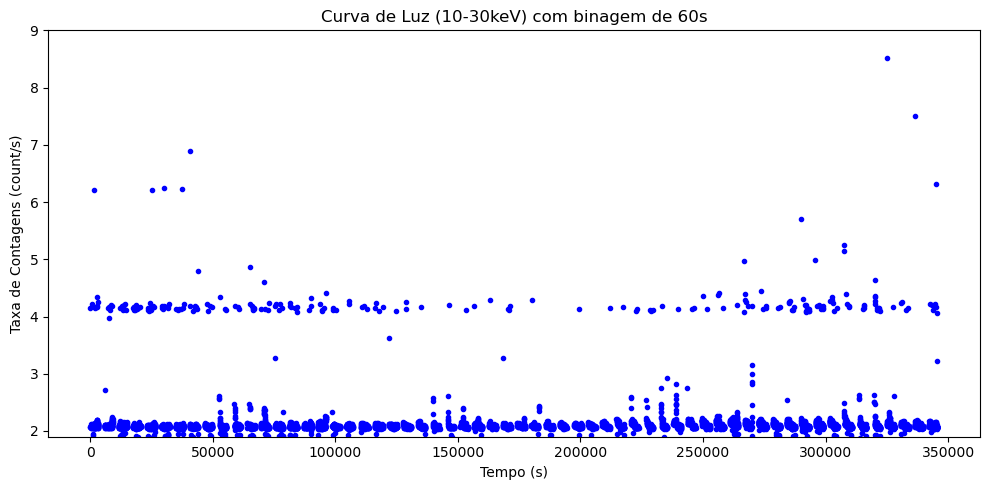

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

caminho = 'data/ bins 60s/10-30kev/lc_fonte_sub_10-30kev.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (10-30keV) com binagem de 60s')
plt.ylim(1.9,9.0)


plt.tight_layout()
plt.show()

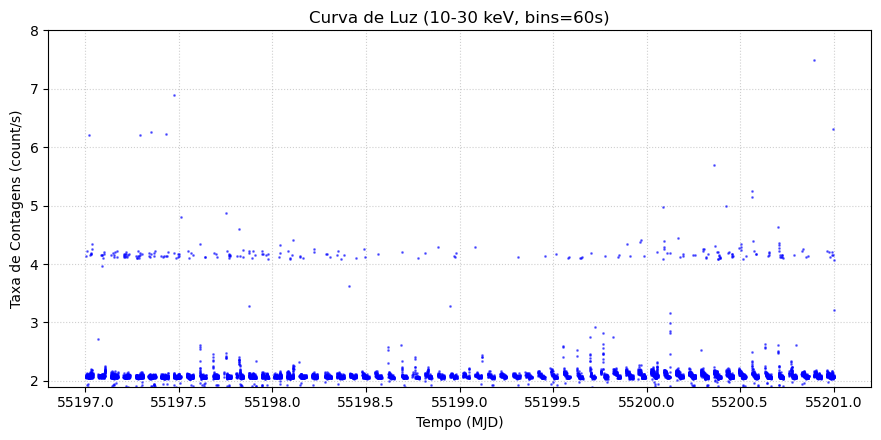

In [51]:
import matplotlib.pyplot as plt
from astropy.table import Table

caminho = 'data/ bins 60s/10-30kev/lc_fonte_sub_10-30kev.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.plot(df['MJD'], df['RATE'], 'b.', alpha=0.5, markersize=2)
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (10-30 keV, bins=60s)')
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.ylim(1.9,8)
plt.show()

Melhor frequência: 14.8547 dias⁻¹ (P = 0.07 dias)
Frequência esperada: 0.2560 dias⁻¹ (P = 3.90603 dias)


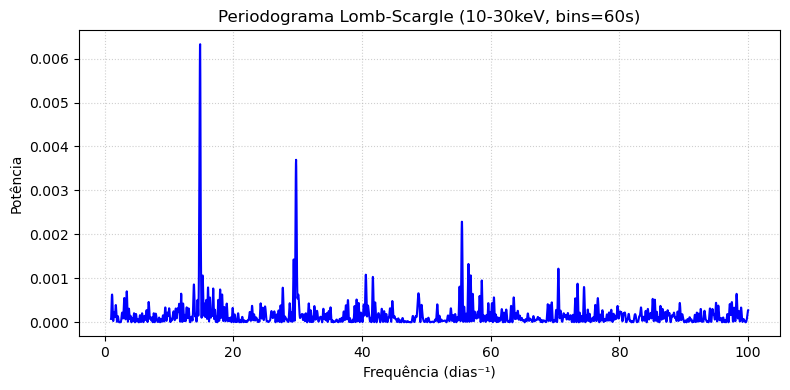

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/ bins 60s/10-30kev/lc_fonte_sub_10-30kev.lc'
tabela = Table.read(caminho, hdu=1)

time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)

t_dias = time[mask] / 86400.0
rate_clean = rate[mask] - np.mean(rate[mask]) 

min_p, max_p = 0.01, 1.0
freq_min, freq_max = 1 / max_p, 1 / min_p

ls = LombScargle(t_dias, rate_clean, err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max, samples_per_peak=10
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

p_esperado = 3.90603  
f_esperado = 1 / p_esperado

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹ (P = {best_p:.2f} dias)')
print(f'Frequência esperada: {f_esperado:.4f} dias⁻¹ (P = {p_esperado} dias)')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'b-', lw=1.5)
#plt.axvline(
 #   f_esperado,
  #  color='r',
   # ls='--',
   # label=f'Esperado (P = {p_esperado} d)',
#)
#plt.axvline(
 #   best_freq, color='k', ls=':', label=f'Pico (P = {best_p:.2f} d)'
#)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle (10-30keV, bins=60s)')
#plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### banda 30-70keV

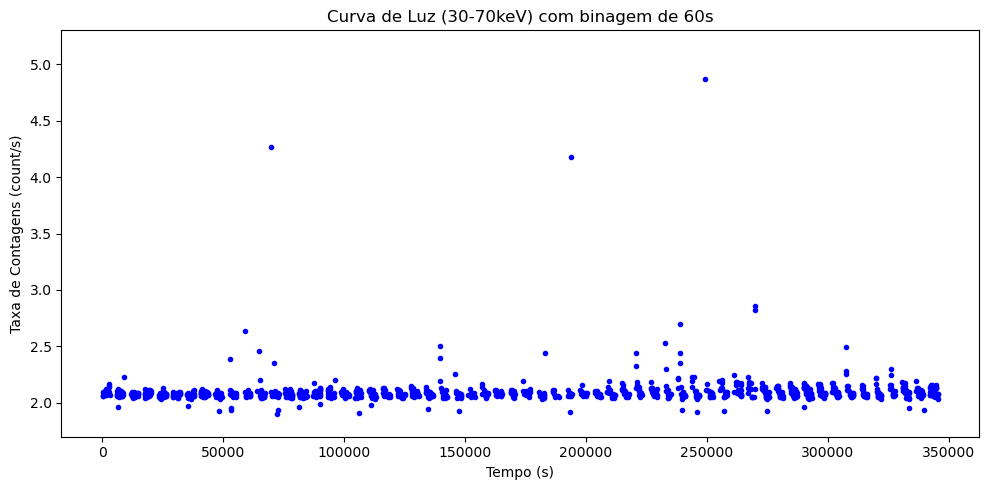

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

# fonte já subtraída do fundo
caminho = 'data/ bins 60s/30-70kev/lc_fonte_sub_30-70kev.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (30-70keV) com binagem de 60s')
plt.ylim(1.7,5.3)


plt.tight_layout()
plt.show()

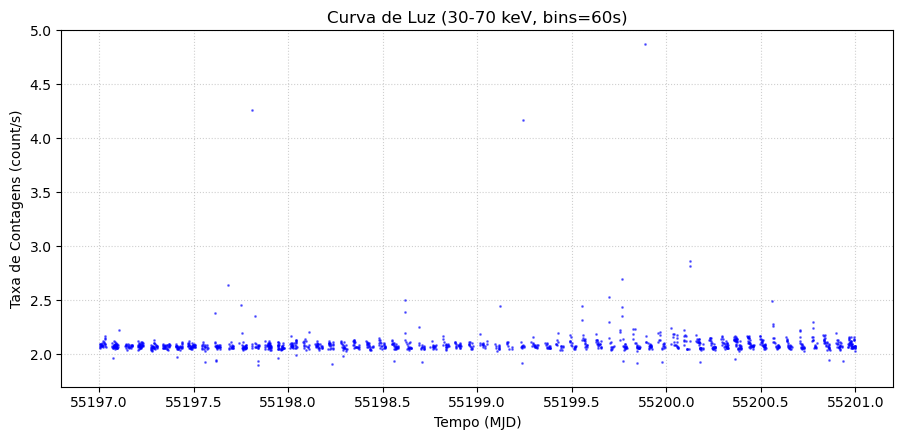

In [49]:
import matplotlib.pyplot as plt
from astropy.table import Table

caminho = 'data/ bins 60s/30-70kev/lc_fonte_sub_30-70kev.lc'
tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.plot(df['MJD'], df['RATE'], 'b.', alpha=0.5, markersize=2)
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (30-70 keV, bins=60s)')
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.ylim(1.7,5)
plt.show()

Melhor frequência: 14.8433 dias⁻¹ (P = 0.07 dias)
Frequência esperada: 0.2560 dias⁻¹ (P = 3.90603 dias)


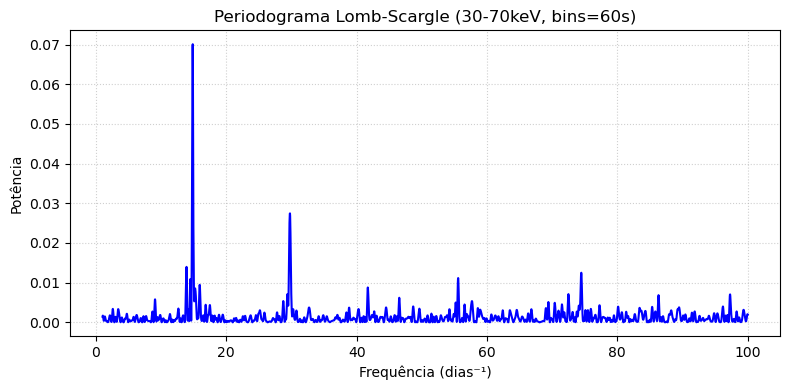

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/ bins 60s/30-70kev/lc_fonte_sub_30-70kev.lc'
tabela = Table.read(caminho, hdu=1)

time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)

t_dias = time[mask] / 86400.0
rate_clean = rate[mask] - np.mean(rate[mask]) 

min_p, max_p = 0.01, 1.0
freq_min, freq_max = 1 / max_p, 1 / min_p

ls = LombScargle(t_dias, rate_clean, err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max, samples_per_peak=10
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

p_esperado = 3.90603  
f_esperado = 1 / p_esperado

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹ (P = {best_p:.2f} dias)')
print(f'Frequência esperada: {f_esperado:.4f} dias⁻¹ (P = {p_esperado} dias)')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'b-', lw=1.5)
#plt.axvline(
 #   f_esperado,
  #  color='r',
   # ls='--',
   # label=f'Esperado (P = {p_esperado} d)',
#)
#plt.axvline(
 #   best_freq, color='k', ls=':', label=f'Pico (P = {best_p:.2f} d)'
#)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle (30-70keV, bins=60s)')
#plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Fator de escala e subtração do fundo

Região ds9: 

Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
physical

circle(439.78884,621.4056,51.533957) # text={bkgA}

circle(462.38115,529.27594,18.984525) # text={srcA}

circle (x,y,radius)

a = Asrc² / Abkg²

data = src - (a * bkg)

propagação de erro:

data = src - a*bkg

sigma_data = sqrt(sigma_src² + a² * sigma_bkg²)

#### 3-10kev 

In [ ]:
import numpy as np
import os  
from astropy.table import Table

path_src = 'data/ bins 60s/3-10kev/nu30201034002A01_sr.lc'
path_bkg = 'data/ bins 60s/3-10kev/nu30201034002A01_bk.lc'

src = Table.read(path_src, hdu=1)
bkg = Table.read(path_bkg, hdu=1)

a = 0.1357101996

rate_sub = src['RATE'] - (a * bkg['RATE'])
err_sub = np.sqrt(src['ERROR'] ** 2 + (a * bkg['ERROR']) ** 2)

lc_clean = src.copy()
lc_clean['RATE'] = rate_sub
lc_clean['ERROR'] = err_sub

origin = os.path.dirname(path_src)

new = 'lc_fonte_sub_3-10kev.lc'
path_out = os.path.join(origin, new)

lc_clean.write(path_out, format='fits', overwrite=True)

print(f"Sucesso! Arquivo salvo em: {path_out}")

Sucesso! Arquivo salvo em: data/ bins 60s/3-10kev/lc_fonte_sub_3-10kev.lc


#### 10-30kev

In [1]:
import numpy as np
from astropy.table import Table

src = Table.read('data/ bins 60s/10-30kev/nu30201034002A01_sr.lc', hdu=1)
bkg = Table.read('data/ bins 60s/10-30kev/nu30201034002A01_bk.lc', hdu=1)

# Fator de escala
a = 0.1357101996

# subtração do fundo corrigido 
# propagação de erro
rate_sub = src['RATE'] - (a * bkg['RATE'])
err_sub = np.sqrt(src['ERROR'] ** 2 + (a * bkg['ERROR']) ** 2)

lc_clean = src.copy()
lc_clean['RATE'] = rate_sub
lc_clean['ERROR'] = err_sub

lc_clean.write('lc_fonte_sub_10-30kev.lc', format='fits', overwrite=True)

#### 30-70kev

In [29]:
import numpy as np
from astropy.table import Table

src = Table.read('data/ bins 60s/30-70kev/nu30201034002A01_sr.lc', hdu=1)
bkg = Table.read('data/ bins 60s/30-70kev/nu30201034002A01_bk.lc', hdu=1)

# Fator de escala
a = 0.1357101996

# subtração do fundo corrigido 
# propagação de erro
rate_sub = src['RATE'] - (a * bkg['RATE'])
err_sub = np.sqrt(src['ERROR'] ** 2 + (a * bkg['ERROR']) ** 2)

lc_clean = src.copy()
lc_clean['RATE'] = rate_sub
lc_clean['ERROR'] = err_sub

lc_clean.write('lc_fonte_sub_30-70kev.lc', format='fits', overwrite=True)